# **Summer Analytics Week 2 Hackathon**





### **Step 1: Import Libraries**

We start by importing `pandas` for loading and manipulating data, and a few utilities from `scikit-learn` for preprocessing and modelling.
These are all standard libraries that come pre-installed in most Python environments like Kaggle, Colab, or Anaconda.
No additional installations are required to run this notebook.


In [618]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


### **Step 2: Load Data**

We read all three CSV files — `train.csv`, `public_test.csv`, and `private_test.csv` — into pandas DataFrames.
The train set contains labelled examples we will learn from, the public_test set will be used for validation. while the private_test set is what we need to make final predictions on.
Printing the shapes gives a quick sanity check that the files loaded correctly.


In [619]:
train = pd.read_csv("train.csv")
public_test = pd.read_csv("public_test.csv")
private_test = pd.read_csv("private_test.csv")

print("Train Shape:", train.shape)
print("Public Test Shape:", public_test.shape)
print("Private Test Shape:", private_test.shape)

train.head()


Train Shape: (10000, 14)
Public Test Shape: (3000, 14)
Private Test Shape: (3000, 13)


,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


### **Step 3: Exploratory Data Analysis (EDA)**

Statistical Summary of Train set was calculated  to observe the mean, median, std deviation, min and max values. Missing value was checked and Unique values were counted for each variable. Histograms were plotted for each variable to see the distribution & skewness and pair plot was used to analyze the correlations among variables.

In [620]:
train.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
count,10000.00000,8520.000000,9016.000000,10000.000000,10000.00000,10000.000000,8152.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,41.457746,69961.772797,1.933400,15.60850,15.219300,13.667241,2.972500,0.540700,12.473900,5511.162200,0.30870
std,2886.89568,13.770164,24790.673822,0.737712,8.62346,8.927563,19.438244,1.738691,0.498366,6.892856,2596.933802,0.46198
min,1.00000,18.000000,12000.000000,1.000000,1.00000,1.000000,0.800000,0.000000,0.000000,1.000000,1000.000000,0.00000
25%,2500.75000,29.000000,52294.644359,1.000000,8.00000,8.000000,7.640000,2.000000,0.000000,7.000000,3251.750000,0.00000
50%,5000.50000,41.000000,70171.613672,2.000000,16.00000,15.000000,11.145000,3.000000,1.000000,12.000000,5515.500000,0.00000
75%,7500.25000,53.000000,86907.747154,2.000000,23.00000,23.000000,15.630000,4.000000,1.000000,18.000000,7759.000000,1.00000
max,10000.00000,65.000000,161687.774167,3.000000,30.00000,37.000000,607.390000,12.000000,1.000000,24.000000,9998.000000,1.00000


In [621]:
# check number of missing value
train.isnull().sum()

,0
User_ID,0
Age,1480
Income,984
City_Tier,0
Device_Type,0
Traffic_Source,0
Pages_Viewed,0
Products_Viewed,0
Time_On_Site,1848
Previous_Purchases,0


In [622]:
# unique values in each variable
train.nunique()

,0
User_ID,10000
Age,48
Income,8944
City_Tier,3
Device_Type,3
Traffic_Source,5
Pages_Viewed,30
Products_Viewed,37
Time_On_Site,2381
Previous_Purchases,13


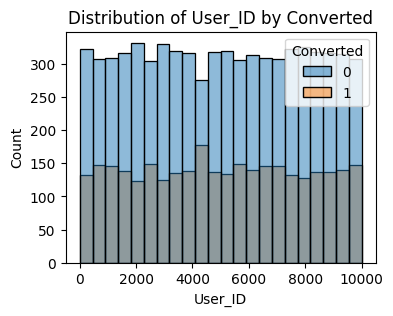

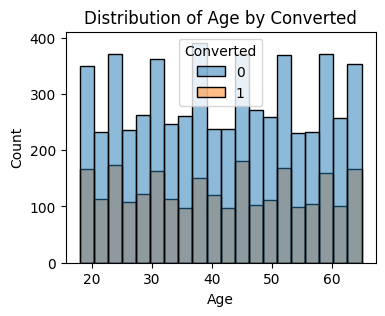

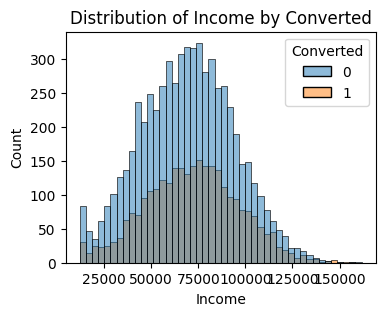

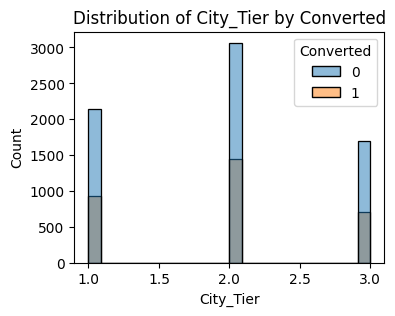

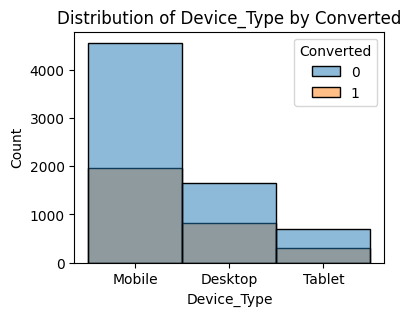

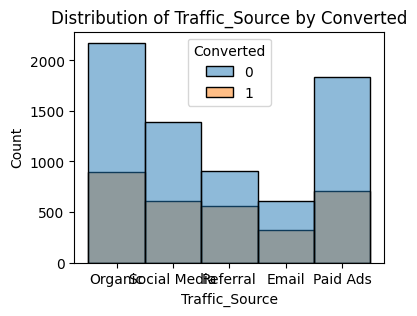

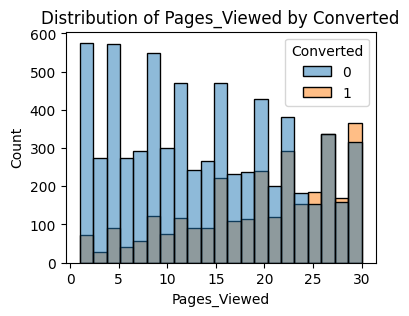

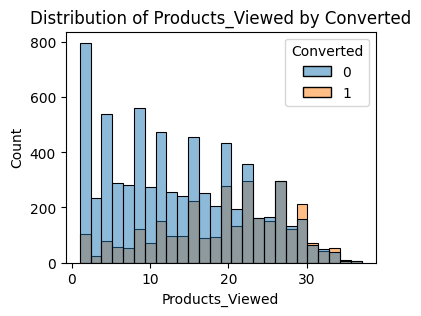

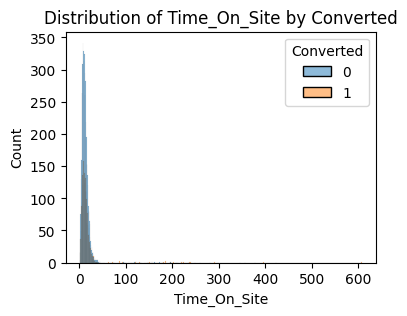

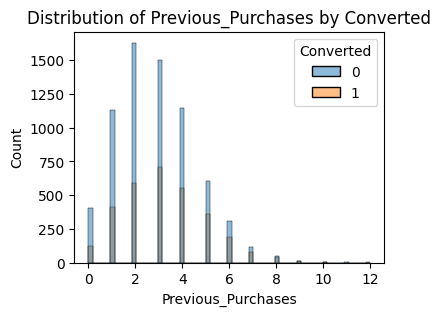

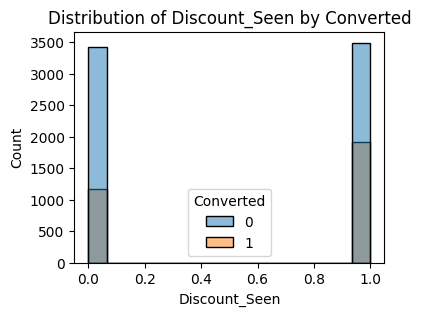

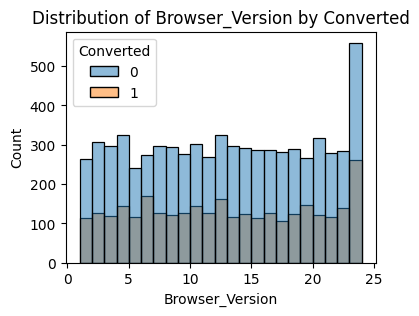

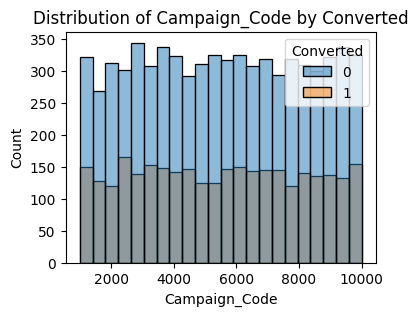

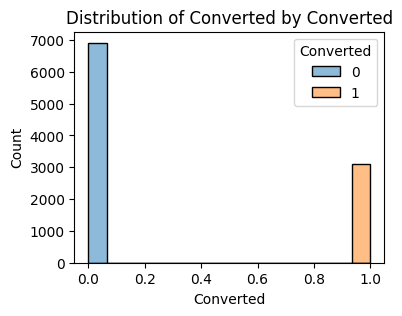

In [623]:
# Plot to check the distribution of variables
# observations: There is clear class imbalance observed. There are few outliers observed in Time_On_Site variable.

import seaborn as sns
import matplotlib.pyplot as plt

for col in train.columns:
  plt.figure(figsize=(4, 3))  # Slightly wider to fit the legend
  sns.histplot(data=train, x=col, hue="Converted")
  plt.title(f"Distribution of {col} by {"Converted"}")
  plt.show()



In [624]:
# pair-plot to visualize how each variables are correlated. (OPTIONAL)
# There is hardly any correlations observed except the fact that Product_Viewed and Pages_Viewed are highly correlated.
# One of them can be dropped, but we are keeping both.

# sns.pairplot(train, hue='Converted')
# plt.show()

### **Step 4: Feature Selection**

We separated the target column (`Converted`) from the rest of the features in the training set. User_ID and Campaign_Code were removed because they represent unique identifiers and do not contribute towards prediction. Same operation was performed for the public as well as private data.




In [625]:
TARGET = "Converted"

# Columns to be dropped.
# User_ID and Campaign_Code are unique identifiers, by logic they do not directly affect client conversion.
DROP_COLS = ["User_ID", "Campaign_Code"]


# Separate features and target for all datasets
X_train = train.drop(columns=[TARGET] + DROP_COLS)
y_train = train[TARGET]

X_test = public_test.drop(columns=[TARGET] + DROP_COLS)
y_test = public_test[TARGET]

X_private = private_test.drop(columns=DROP_COLS)

### **Step 5: Feature Engineering**

Ratio of `product pages viewed to total pages viewed` was transformed as a new feature. Interaction features were tested and out of them (`Previous_Purchases * Products_Viewed`) has been selected for best results.

In [626]:
# Feature-1: Ratio of product pages viewed to total pages viewed.
# To capture browsing activity
X_train["Products_Per_Page"] = (
    X_train["Products_Viewed"] /
    (X_train["Pages_Viewed"])
)

X_test["Products_Per_Page"] = (
    X_test["Products_Viewed"] /
    (X_test["Pages_Viewed"])
)

X_private["Products_Per_Page"] = (
    X_private["Products_Viewed"] /
    (X_private["Pages_Viewed"])
)

# Feature 2: Interaction between previous purchases and products viewed.
# Captures how engaged returning customers are.
X_train["PurchaseHistory_x_Products"] = (
    X_train["Previous_Purchases"] *
    X_train["Products_Viewed"]
)

X_test["PurchaseHistory_x_Products"] = (
    X_test["Previous_Purchases"] *
    X_test["Products_Viewed"]
)

X_private["PurchaseHistory_x_Products"] = (
    X_private["Previous_Purchases"] *
    X_private["Products_Viewed"]
)



**Outlier Handling**

The Time_On_Site variable showed a skewed distribution. To reduce the effect of these outliers, the variable was capped at its 99th percentile value. The categorical variables Device_Type and Traffic_Source were transformed into numeric values using one-hot encoding.

In [627]:
# Handling outliers on Time_On_Site varaible by capping. It will Treat all very large Time_On_Site values similarly.

cap = X_train["Time_On_Site"].quantile(0.991)

X_train["Time_On_Site"] = X_train["Time_On_Site"].clip(upper=cap)
X_test["Time_On_Site"] = X_test["Time_On_Site"].clip(upper=cap)
X_private["Time_On_Site"] = X_private["Time_On_Site"].clip(upper=cap)


In [628]:
# One-hot encoding for converting categorical variables to numerical
combined = pd.concat(
    [X_train, X_test, X_private],
    axis=0
)

combined = pd.get_dummies(
    combined,
    columns=["Device_Type", "Traffic_Source"],
    drop_first=True
)

# Split back
X_train = combined.iloc[:len(X_train)]
X_test = combined.iloc[len(X_train):len(X_train)+len(X_test)]
X_private = combined.iloc[len(X_train)+len(X_test):]

print("Shape after encoding:", X_train.shape)
print("Shape after encoding:", X_test.shape)
print("Shape after encoding:", X_private.shape)



Shape after encoding: (10000, 17)
Shape after encoding: (3000, 17)
Shape after encoding: (3000, 17)


### **Step 6: Data Preprocessing: Handle Missing Values & Scale Features**

Missing numerical values were imputed using the median. Added “add_indicator=True” to preserve information about missingness. All features were  standardized using StandardScaler to make sure that the variables were on the same scale. We fit both the imputer and scaler only on the training data, then apply the same transformation to the test data to avoid data leakage.


In [629]:
# Fill missing values with the median of each column
# add_indicator creates a new binary column for each variable that had missing values to flag where the missing data used to be.
imputer = SimpleImputer(strategy="median", add_indicator=True)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
X_private_imputed = imputer.transform(X_private)

# Scale features to zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
X_private_scaled = scaler.transform(X_private_imputed)



### **Step 7: Train a Logistic Regression Model**

A Logistic Regression model was trained using class_weight=‘balanced’ to resolve the class imbalance problem.
We set `max_iter=1000` to ensure the solver has enough iterations to converge on this dataset.


In [630]:
from sklearn.svm import SVC
# As the target variable was imbalanced (more non-converted(0) than converted customers(1)),
# class_weight="balanced" was used to improve the model and improve the F1 score.
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("Training Accuracy: {:.4f}".format(model.score(X_train_scaled, y_train)))


Model trained successfully!
Training Accuracy: 0.6732


### **Step 8: Model Prediction on public set**

Model prediction was performed on the validation data to check the evaluation metrics(Accuracy, Precision, Recall, F1-Score, confusion matrix) and evaluate the model.

In [631]:
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\n")
print("F1 Score:", f1_score(y_test, y_pred))


Confusion Matrix:
 [[1405  709]
 [ 267  619]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.66      0.74      2114
           1       0.47      0.70      0.56       886

    accuracy                           0.67      3000
   macro avg       0.65      0.68      0.65      3000
weighted avg       0.73      0.67      0.69      3000

Accuracy: 0.6746666666666666
Precision: 0.4661144578313253
Recall: 0.698645598194131


F1 Score: 0.5591689250225835


### **Step 9: Final Prediction on Private Set and Create Submission**

We run the best performing model on the scaled private test data to generate our final predictions.
The predictions are combined with the `User_ID` column into a DataFrame matching the required submission format.



In [632]:
predictions = model.predict(X_private_scaled)
submission = pd.DataFrame({
    "User_ID": private_test["User_ID"],
    "Converted": predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")
submission.head()


submission.csv created successfully!


,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,1
4,103005,0
